# Feature Engineering и временной split

Подготовка данных перед обучением моделей.

## 1. Загружаем очищенные данные

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_parquet(
    "../data/interim/hotel_bookings_clean.parquet"
)

df.shape

(119390, 32)

## 2. Восстанавливаем дату создания бронирования

Наша задача — сделать прогноз в момент создания брони. Поэтому делить данные по дате заезда неправильно.

Сначала собираю `arrival_date`, затем вычитаю `lead_time` и получаю примерную дату бронирования.

In [2]:
df["arrival_date"] = pd.to_datetime(
    df["arrival_date_year"].astype(str)
    + "-"
    + df["arrival_date_month"].astype(str)
    + "-"
    + df["arrival_date_day_of_month"].astype(str),
    format="%Y-%B-%d"
)

df["booking_date"] = (
    df["arrival_date"]
    - pd.to_timedelta(df["lead_time"], unit="D")
)

df[["arrival_date", "booking_date", "lead_time"]].head()

,arrival_date,booking_date,lead_time
0,2015-07-01,2014-07-24,342
1,2015-07-01,2013-06-24,737
2,2015-07-01,2015-06-24,7
3,2015-07-01,2015-06-18,13
4,2015-07-01,2015-06-17,14


### Посмотрим распределение по времени

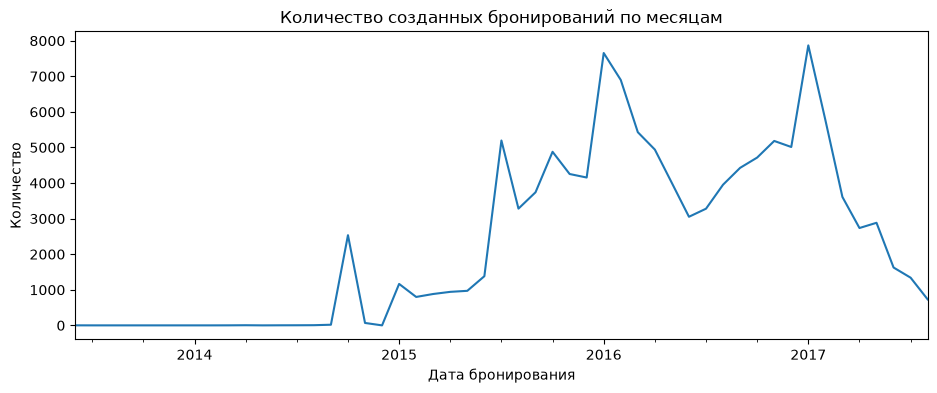

In [3]:
df.set_index("booking_date").resample("MS").size().plot(
    figsize=(11, 4)
)

plt.title("Количество созданных бронирований по месяцам")
plt.xlabel("Дата бронирования")
plt.ylabel("Количество")
plt.show()

## 3. Добавляем признаки из EDA

### Общее количество гостей

In [4]:
df["total_guests"] = (
    df["adults"]
    + df["children"].fillna(0)
    + df["babies"]
)

### Общее количество ночей

In [5]:
df["total_nights"] = (
    df["stays_in_week_nights"]
    + df["stays_in_weekend_nights"]
)

### Были ли у клиента отмены раньше

In [6]:
df["has_previous_cancellation"] = (
    df["previous_cancellations"] > 0
).astype(int)

### Бронирование с нулевой стоимостью

In [7]:
df["is_zero_adr"] = (df["adr"] == 0).astype(int)

## 4. Временной split

Данные идут строго из прошлого в будущее:

- `train` — всё до ноября 2016;
- `validation` — ноябрь 2016 — январь 2017;
- `test` — февраль — апрель 2017, первые данные после запуска LightGBM v1;
- `production` — май — август 2017, этот период оставляю нетронутым для финального мониторинга CatBoost v2.

In [8]:
train = df[
    df["booking_date"] < "2016-11-01"
].copy()

validation = df[
    (df["booking_date"] >= "2016-11-01")
    & (df["booking_date"] < "2017-02-01")
].copy()

test = df[
    (df["booking_date"] >= "2017-02-01")
    & (df["booking_date"] < "2017-05-01")
].copy()

production = df[
    df["booking_date"] >= "2017-05-01"
].copy()

### Проверим размеры и даты

In [9]:
splits = {
    "train": train,
    "validation": validation,
    "test": test,
    "production": production,
}

summary = []

for name, data in splits.items():
    summary.append({
        "split": name,
        "rows": len(data),
        "date_from": data["booking_date"].min(),
        "date_to": data["booking_date"].max(),
        "cancellation_rate": data["is_canceled"].mean(),
    })

pd.DataFrame(summary).set_index("split")

,rows,date_from,date_to,cancellation_rate
split,,,,
train,82629,2013-06-24,2016-10-31,0.380109
validation,18065,2016-11-01,2017-01-31,0.392804
test,12117,2017-02-01,2017-04-30,0.325906
production,6579,2017-05-01,2017-08-31,0.269190


Важный момент: февраль–апрель сначала используются только для проверки уже выбранной LightGBM. После появления фактических ответов февраль и март можно добавить в историю для CatBoost, а апрель оставить последним контрольным месяцем перед новой выкладкой.

Май–август до этого момента нигде не используются.

## 5. Сохраняем выборки

In [10]:
Path("../data/processed").mkdir(parents=True, exist_ok=True)

train.to_parquet(
    "../data/processed/train.parquet",
    index=False
)

validation.to_parquet(
    "../data/processed/validation.parquet",
    index=False
)

test.to_parquet(
    "../data/processed/test.parquet",
    index=False
)

production.to_parquet(
    "../data/processed/production.parquet",
    index=False
)

## Вывод

Получился обычный временной сценарий, похожий на реальную работу модели. Сначала обучаемся на прошлом, затем запускаем LightGBM и смотрим, что произошло на следующих трёх месяцах. Только после появления ответов переобучаем новую модель. Финальный период май–август остаётся независимым.